# Exercises to Statistical Methods and Analysis Techniques in Experimental Physics
## Exercise 1, February 18th, 2025

## 1) Summary statistics

In [4]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons
from scipy.stats import multivariate_normal
import numpy as np


In [54]:
def generate_dataset(N, seed=42):
    np.random.seed(seed)
    # Define mean vector (center of the distribution)
    mean = [1, -0.5, 1.2]
    # Define covariance matrix (controls relationships between features)
    cov = [
        [3,     -0.8,  1.2],
        [-0.8,  1.5,   0.5],
        [1.2,   0.5,   2]
    ]
    # Sample N points from the multivariate normal distribution
    X = np.random.multivariate_normal(mean, cov, size=N)
    X2, Y = make_moons(n_samples=N, noise=0.05, random_state=seed)
    X3 = np.random.poisson(1, size=N) #+ np.random.normal(0, 0.3, size=N)
    
    data = np.concatenate([X, X2, X3[:,None]], axis=1)
    return data



In [55]:
N = 10000
X = generate_dataset(N, seed=42)

You have a dataset consisting of multiple observations of 6 quantities, measured in a lab experiment: temperature, pression, position, speed, accelerationl, number of particles.

- Each "row" in the dataset corresponds to a different observation.
- Each "column" in the dataset corresponds to a different features or measurement of your observation.

**Your goal for this first exercise is to compute the summary statistics for each of the quantity measured in the experiment**:
- How the features are distributed?
    - Compute the mean and the std value of each features
    - Compute the median and the mode of the distributions "by hand", then try with python libraries methods.
    - Compute the quantiles of each feature
      
- How they are correlated? Compute the covariance matrix of the features and the correlation.
- Compute higher order momenta of the distributions.
- Before doing any histogram, how do you expect the numbers are distributed? Do you think they are gaussian or having a different distribution?  (_don't look too close to the dataset generating code_ ;) )

### Mean and standard deviation

Manual computation:

In [22]:
mean**2 - np.sum(X**2, axis=0)/(N-1)

array([-3.00901072, -1.51201155, -1.99924125, -0.75240483, -0.24610838,
       -0.51687649])

In [28]:
mean = np.sum(X, axis=0) / N

std = np.sqrt( np.sum( (X - mean)**2, axis=0) / (N-1))

print(f"Mean: {mean}")
print(f"Std: {std}")

Mean: [ 1.00974188 -0.50580797  1.20383297  0.50057444  0.24972914  0.5005    ]
Std: [1.73462064 1.22962838 1.41389402 0.86739828 0.49608683 0.7189238 ]


Python libs computation:

In [29]:
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)

print(f"Mean: {mean}")
print(f"Std: {std}")

Mean: [ 1.00974188 -0.50580797  1.20383297  0.50057444  0.24972914  0.5005    ]
Std: [1.7345339  1.2295669  1.41382333 0.86735491 0.49606203 0.71888786]


### Median and Mode

Manual computation:

In [56]:
#the median function, taking a list/array as input
def median(lst):
    n = len(lst)
    if n < 1:
            return None
    if n % 2 == 1:
            return sorted(lst)[n//2]
    else:
            return sum(sorted(lst)[n//2-1:n//2+1])/2.0

for i in range(6):
    x = X[:,i]
    xsorted = np.sort(x, axis=0)
    print(f"Median for feature {i}: {median(xsorted)}")

Median for feature 0: 1.0180245690183316
Median for feature 1: -0.5029127989588167
Median for feature 2: 1.1945138833325277
Median for feature 3: 0.5010478249876362
Median for feature 4: 0.24677977412629765
Median for feature 5: 1.0


Mode computation: 

We need to find the value with the maximum probability. We should use histograms for this, but we can for the moment just split the features domain in small intervals and find the interval with the maximum counts.

In [66]:
def find_mode(x, nbins=100):
    xmin, xmax = np.min(x), np.max(x)
    bin = (xmax-xmin)/nbins
    max_bin = -1
    max_value = -1
    for i in range(nbins-1):
        interval =  np.sum((x>= (xmin+bin*i)) & (x<(xmin+bin*i+1)))
        if interval > max_value:
            max_bin = i
            max_value = interval
    # We return the central value of the bin where we found the maximum
    return (xmin+max_bin*bin + bin/2)

In [73]:
for i in range(6):
    mode = find_mode(X[:,i],nbins=100)
    print(f"Mode for feature {i}: {mode:.3f}")

Mode for feature 0: 0.850
Mode for feature 1: -0.930
Mode for feature 2: 0.722
Mode for feature 3: 0.005
Mode for feature 4: -0.518
Mode for feature 5: 0.040


Python libs

### Quantiles

Compute the quantiles of all the features.

In [103]:
Q = np.quantile(X, q=np.linspace(0, 1, 10), axis=0).T
Q

array([[-6.78708659, -1.09871587, -0.31226937,  0.25159733,  0.76822134,
         1.27625781,  1.7351962 ,  2.32865067,  3.09418146,  8.33537842],
       [-5.53879699, -1.9946644 , -1.45114385, -1.03558816, -0.68209695,
        -0.33113207,  0.02835699,  0.45401656,  0.99244638,  3.77139427],
       [-3.82135499, -0.52652481,  0.10781353,  0.61052534,  1.00705569,
         1.39786582,  1.80776789,  2.27842082,  2.94200782,  6.16427198],
       [-1.17329466, -0.76615336, -0.17080387,  0.0983737 ,  0.34969068,
         0.65256802,  0.9028645 ,  1.17426021,  1.7622755 ,  2.14720467],
       [-0.63382904, -0.42933974, -0.26224376, -0.01329712,  0.16330307,
         0.3336698 ,  0.51233325,  0.76496774,  0.92997895,  1.15136841],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  1.        ,
         1.        ,  1.        ,  2.        ,  2.        ,  8.        ]])

### Covariance and correlation

In [112]:
# Each row must have all the observation of each variables
X_features = np.transpose(X)  # or X.T
covariance_matrix = np.cov(X_features)
covariance_matrix

array([[ 3.00890875e+00, -8.35308693e-01,  1.20992858e+00,
        -1.91616507e-02,  6.78440468e-03,  9.96807334e-03],
       [-8.35308693e-01,  1.51198596e+00,  4.81052233e-01,
         1.42922903e-03, -3.39562953e-03, -6.51229145e-03],
       [ 1.20992858e+00,  4.81052233e-01,  1.99909631e+00,
        -1.68884264e-03,  3.06097526e-03, -4.71729727e-04],
       [-1.91616507e-02,  1.42922903e-03, -1.68884264e-03,
         7.52379774e-01, -1.92323141e-01, -5.65996943e-05],
       [ 6.78440468e-03, -3.39562953e-03,  3.06097526e-03,
        -1.92323141e-01,  2.46102144e-01,  4.44752604e-04],
       [ 9.96807334e-03, -6.51229145e-03, -4.71729727e-04,
        -5.65996943e-05,  4.44752604e-04,  1.00579769e+00]])

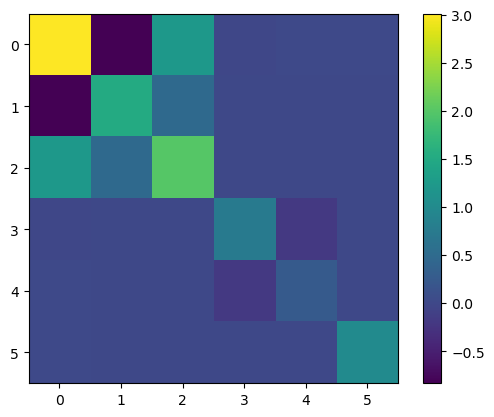

In [115]:
plt.imshow(covariance_matrix)
plt.colorbar()

Now we can compute the correlation matrix:

In [121]:
std_features = np.std(X_features, axis=1)

To compute the denominator for the correlation matrix we can use the matrix moltiplication syntax from numpy:

$$ corr(x_1,x_2) = \frac{cov(x_1,x_2)}{\sqrt{var(x_1)*var(x_2)}}$$

In [133]:
np.expand_dims(std_features, 1)

array([[1.7345339 ],
       [1.2295669 ],
       [1.41382333],
       [0.86735491],
       [0.49606203],
       [1.00284451]])

In [135]:
var_denom = np.expand_dims(std_features, 1) @ np.expand_dims(std_features, 0)
var_denom

array([[3.00860786, 2.13272548, 2.4523245 , 1.50445649, 0.8604364 ,
        1.7394678 ],
       [2.13272548, 1.51183476, 1.73839037, 1.06647089, 0.60994145,
        1.23306442],
       [2.4523245 , 1.73839037, 1.9988964 , 1.2262866 , 0.70134406,
        1.41784496],
       [1.50445649, 1.06647089, 1.2262866 , 0.75230454, 0.43026183,
        0.86982211],
       [0.8604364 , 0.60994145, 0.70134406, 0.43026183, 0.24607753,
        0.49747308],
       [1.7394678 , 1.23306442, 1.41784496, 0.86982211, 0.49747308,
        1.00569711]])

In [137]:
corr = covariance_matrix / var_denom
corr

array([[ 1.00010001e+00, -3.91662547e-01,  4.93380295e-01,
        -1.27365935e-02,  7.88484153e-03,  5.73053053e-03],
       [-3.91662547e-01,  1.00010001e+00,  2.76722790e-01,
         1.34014819e-03, -5.56714015e-03, -5.28138787e-03],
       [ 4.93380295e-01,  2.76722790e-01,  1.00010001e+00,
        -1.37720060e-03,  4.36444167e-03, -3.32708963e-04],
       [-1.27365935e-02,  1.34014819e-03, -1.37720060e-03,
         1.00010001e+00, -4.46990941e-01, -6.50704252e-05],
       [ 7.88484153e-03, -5.56714015e-03,  4.36444167e-03,
        -4.46990941e-01,  1.00010001e+00,  8.94023461e-04],
       [ 5.73053053e-03, -5.28138787e-03, -3.32708963e-04,
        -6.50704252e-05,  8.94023461e-04,  1.00010001e+00]])

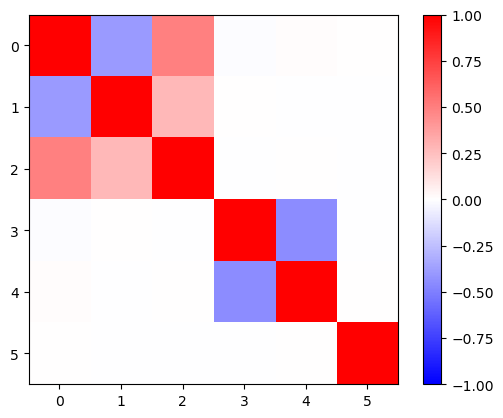

In [141]:
plt.imshow(corr, cmap="bwr", vmin=-1, vmax=1)
plt.colorbar()

# 2) Histogramming

Histograms are tools to estimate a probability density function when samples or "observations" are available. 
In this next part of the exercise you will analyze the dataset by plotting histograms of each measurement feature and also by checking their corrections with 2D histograms.

1) Draw the 1D histogram of all the features in the dataset
2) Draw the 2D histograms of pairs of features.
3) (Bonus) You can  plot then as a "corner" plot, look [here](https://corner.readthedocs.io/en/latest/pages/quickstart/) to take inspiration.

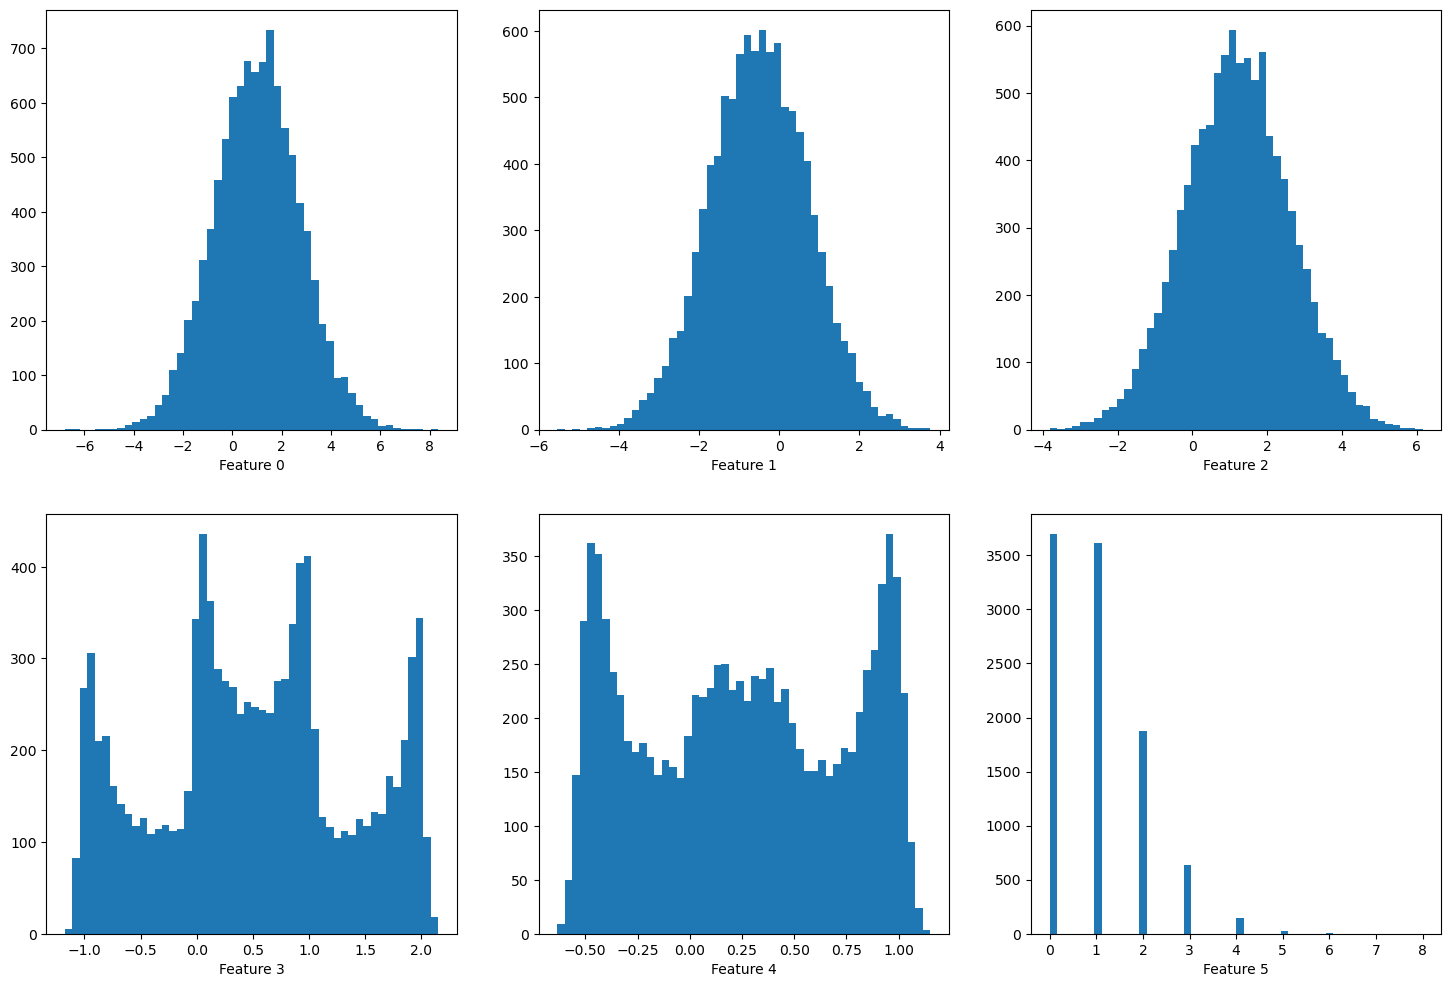

In [147]:
f, axs = plt.subplots(2, 3, figsize=(18,12), dpi=100)

for i in range(6):
    x = X[:,i]
    axs[i//3, i%3].hist(x, bins=50)
    axs[i//3, i%3].set_xlabel(f"Feature {i}")

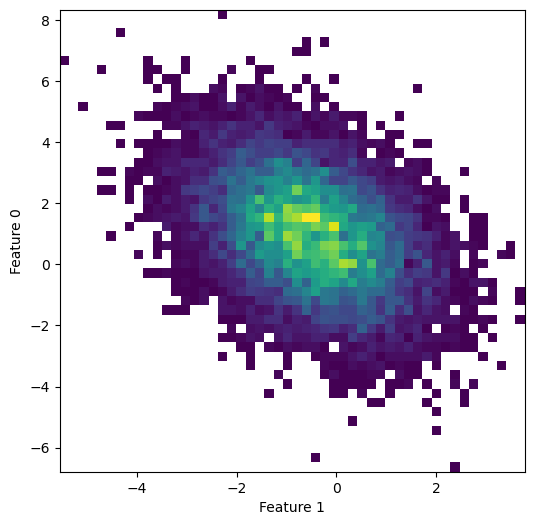

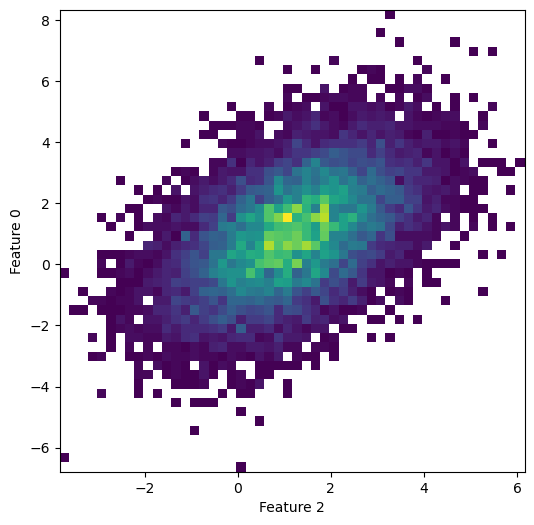

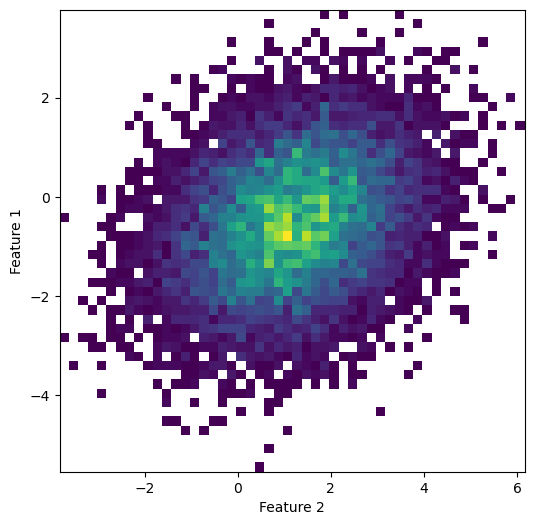

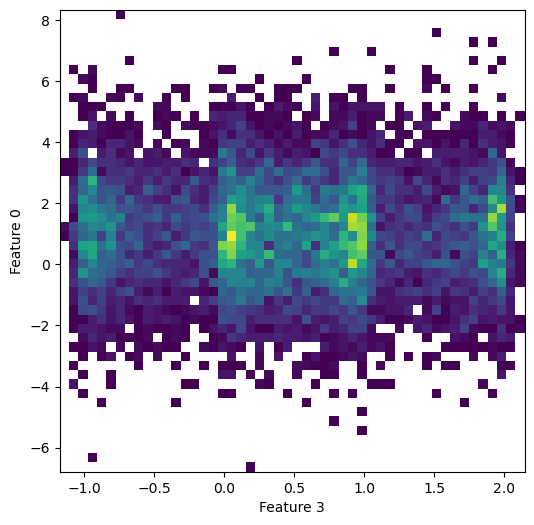

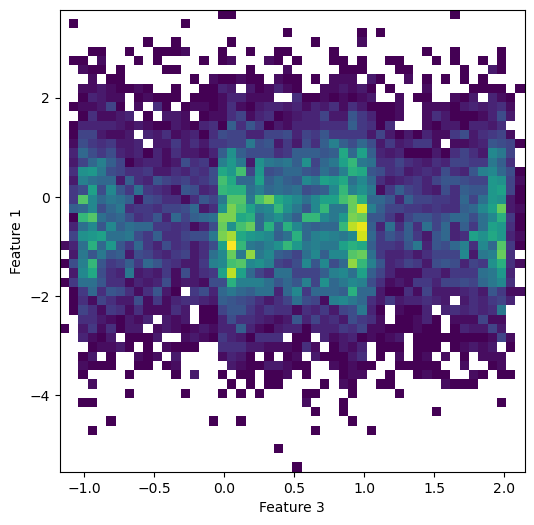

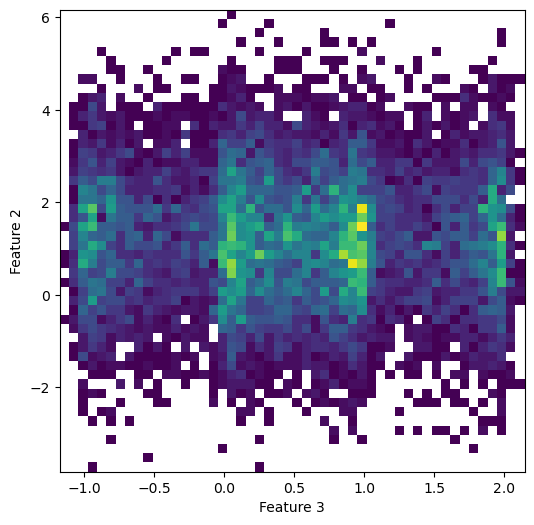

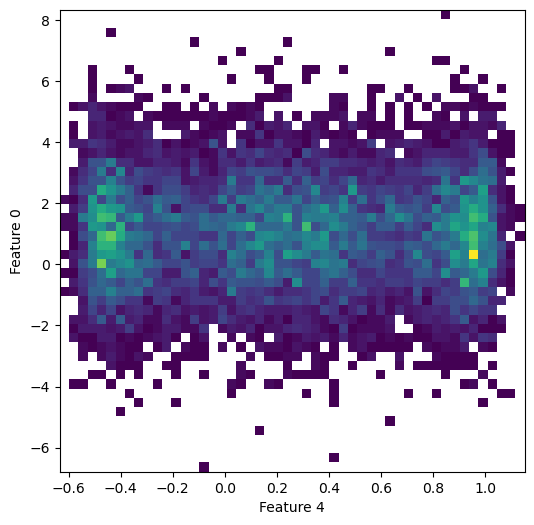

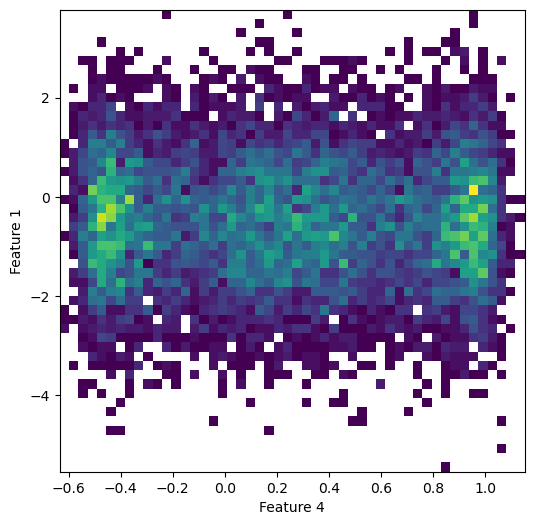

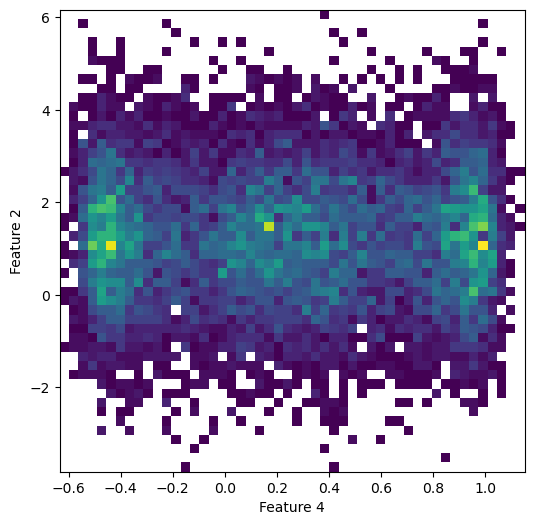

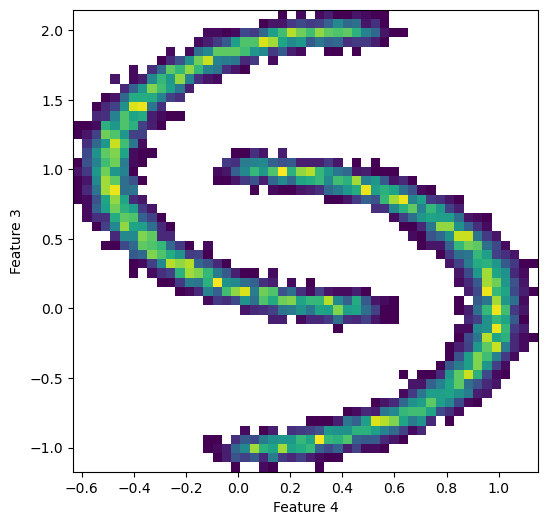

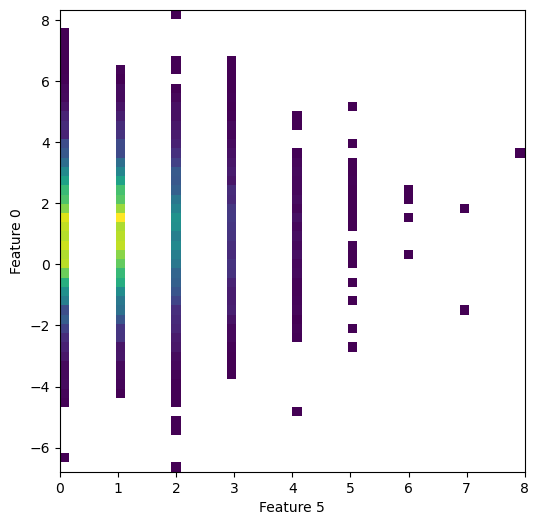

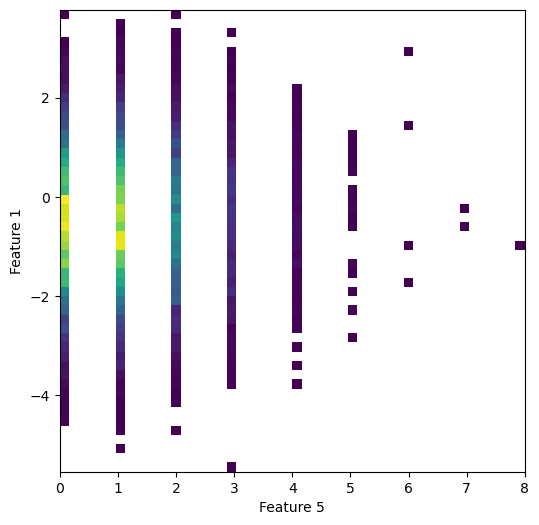

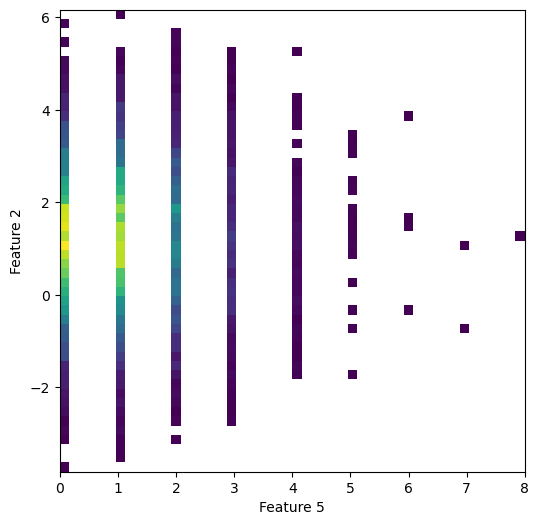

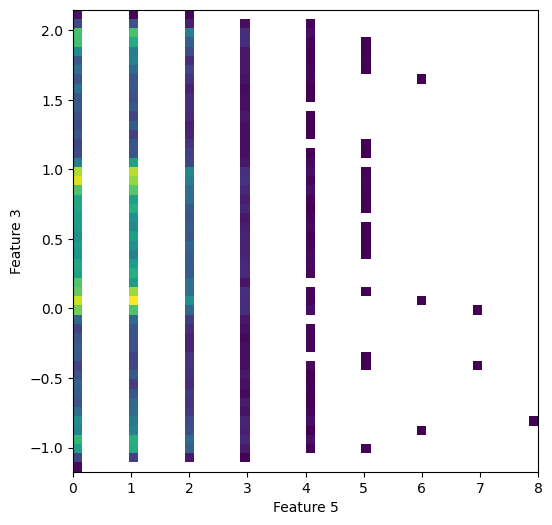

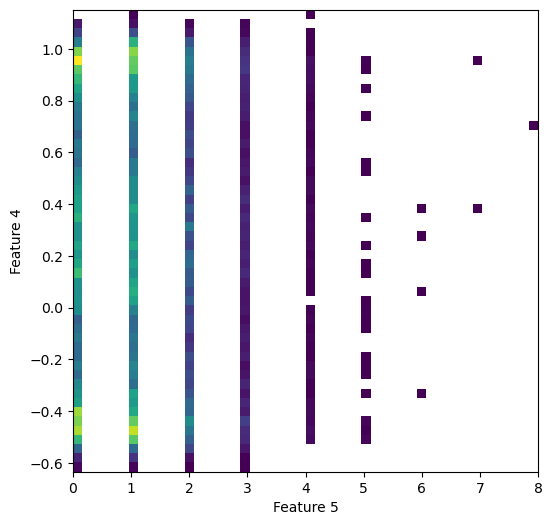

In [167]:
for i in range(6):
    for j in range(6):
        if j>=i: continue
        x = X[:,i]
        y = X[:,j]
        f = plt.figure(figsize=(6,6))
        plt.hist2d(x, y, bins=50, cmap="viridis", cmin=1)
        plt.xlabel(f"Feature {i}")
        plt.ylabel(f"Feature {j}")
        plt.show()

### Bonus
Corner plot

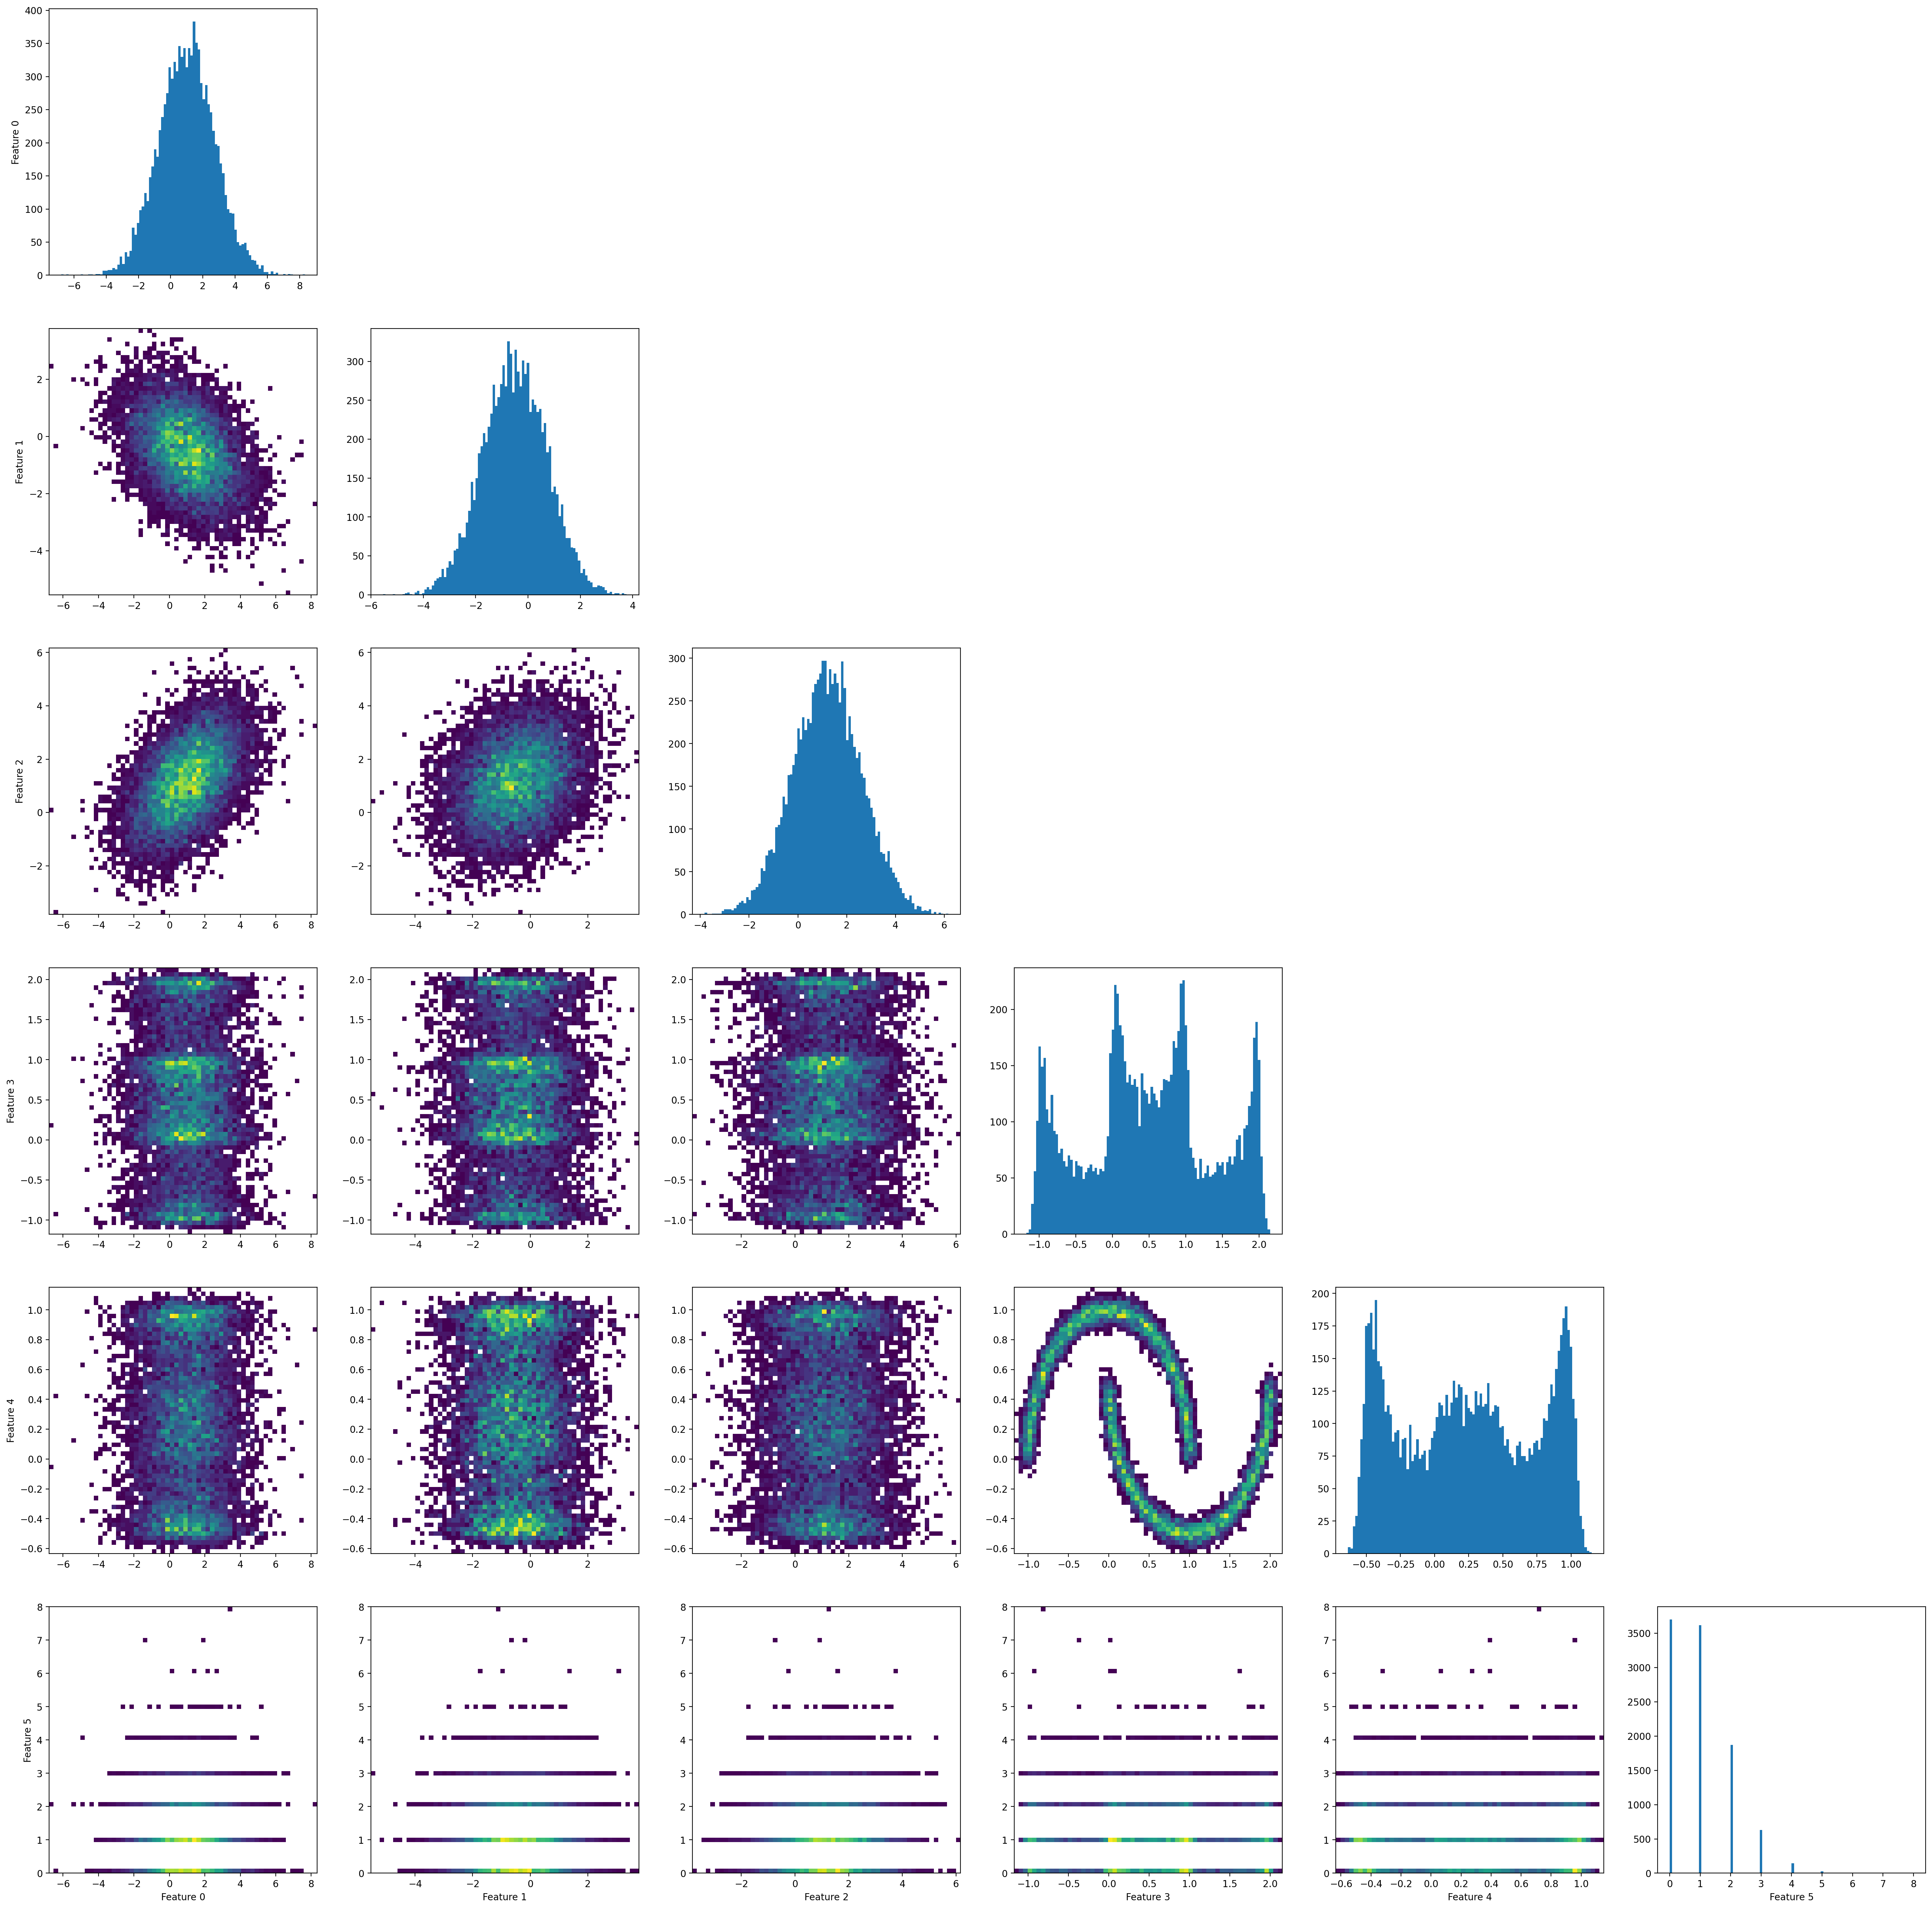

In [169]:
f, axs = plt.subplots(6,6, figsize=(36, 36), dpi=200)

for i in range(6):
    for j in range(6):
        x = X[:,i]
        y = X[:,j]
        if i == j:
            axs[i][j].hist(x, bins=100)
            if j == 5:
                axs[i][j].set_xlabel(f"Feature {i}")
            if i == 0:
                axs[i][j].set_ylabel(f"Feature {i}")
        elif j>i:
            axs[i][j].remove()
        else:
            axs[i][j].hist2d(y, x, bins=60, cmap="viridis", cmin=1)
            if i == 5:
                axs[i][j].set_xlabel(f"Feature {j}")
            if j == 0:
                axs[i][j].set_ylabel(f"Feature {i}")

# Application of the Bayes theorem